# Pràctica 2 — Neteja, imputació i feature engineering

**Input:** `data/raw/pisos_catalunya_20260405.csv` (10.864 anuncis × 34 columnes)
**Output:** `data/processed/pisos_clean.{parquet,csv}` — dataset llest per a la
fase d'estadística inferencial (FASE 3) i de modelat (FASE 4).

**Cinc decisions clau d'aquesta fase, totes justificades a la memòria:**

1. **Província 100% per *spatial join* (GADM ESP nivell 2)** en lloc d'inferir-la
   del text de `locality` — passem del 91.5% del diccionari curat al 100%.
2. **Recuperació de coordenades fora rang** dividint per 1000 — l'EDA va
   detectar que les 142 anomalies tenen un patró d'escala consistent.
3. **Mask de booleans de detall** quan l'anunci no es va visitar al detall
   (proxy: `energy_cert` NaN). Resol un bug semàntic important: al CSV cru,
   `has_terrace=False` barreja "no té terrassa" amb "no s'ha visitat la fitxa".
4. **Imputació estratificada per `property_type`** — la mediana de `rooms`
   d'un Pis (3) i d'una Casa (5) divergeixen prou per justificar-ho.
5. **Marcatge d'anomalies amb flag (no eliminació)** — `is_price_anomaly`,
   `is_rural` permeten excloure-les del modelat principal sense perdre-les
   per a anàlisis específics.

Tota la lògica viu a `src/cleaning.py` i `src/features.py`; el notebook només
orquestra i comenta.


## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100


def find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("project root not found")


PROJECT_ROOT = find_project_root()
RAW_PATH  = PROJECT_ROOT / "data" / "raw" / "pisos_catalunya_20260405.csv"
GADM_PATH = PROJECT_ROOT / "data" / "raw" / "geo" / "gadm41_ESP_2.json.zip"
PROC_DIR  = PROJECT_ROOT / "data" / "processed"
FIG_DIR   = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR   = PROJECT_ROOT / "outputs" / "tables"
for d in (PROC_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import cleaning, features, plots, stats  # noqa: E402

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw CSV      : {RAW_PATH.exists()} ({RAW_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"GADM         : {GADM_PATH.exists()} ({GADM_PATH.stat().st_size / 1e3:.1f} KB)")


Project root : C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia
Raw CSV      : True (9.7 MB)
GADM         : True (243.2 KB)


## 1. Càrrega del dataset cru

In [2]:
df_raw = pd.read_csv(RAW_PATH, delimiter=";", encoding="utf-8-sig")
print(f"Shape raw : {df_raw.shape}")
df = df_raw.copy()


Shape raw : (10864, 34)


## 2. Tipificació explícita

Pandas ja infereix bé la majoria de tipus al `read_csv`. Aquí només forcem la
data de scraping a `datetime` (no aporta valor predictiu però sí auditoria).


In [3]:
for col in ("scrape_date", "scrape_timestamp"):
    df[col] = pd.to_datetime(df[col], errors="coerce")
df[["scrape_date", "scrape_timestamp"]].dtypes


scrape_date         datetime64[ns]
scrape_timestamp    datetime64[ns]
dtype: object

## 3. Recuperació de coordenades fora rang

L'EDA va detectar 142 anuncis amb `latitude` o `longitude` fora del rang
geogràfic de Catalunya. Inspecció: **tots** tenen un factor 1000 erroni
(p. ex. `lat=40812.0` quan hauria de ser `40.812`). El patró és inequívoc i
recuperable.


In [4]:
before = cleaning.detect_anomalies(df)[
    cleaning.detect_anomalies(df).tipus.isin(["lat_out_of_range", "lon_out_of_range"])
]
df = cleaning.recover_coordinates(df)
after  = cleaning.detect_anomalies(df)[
    cleaning.detect_anomalies(df).tipus.isin(["lat_out_of_range", "lon_out_of_range"])
]
print("Abans:")
print(before.to_string(index=False))
print("\nDesprés:")
print(after.to_string(index=False))


Abans:
           tipus                                     descripcio  conteig   pct
lat_out_of_range latitude fora de [40.0, 43.0] — error d'escala      127 1.169
lon_out_of_range  longitude fora de [0.0, 4.0] — error d'escala       15 0.138

Després:
           tipus                                     descripcio  conteig  pct
lat_out_of_range latitude fora de [40.0, 43.0] — error d'escala        0  0.0
lon_out_of_range  longitude fora de [0.0, 4.0] — error d'escala        0  0.0


## 4. Província per *spatial join* (GADM ESP nivell 2)

Substituïm el diccionari curat (91.5% cobertura) per un *spatial join* contra
els polígons de províncies espanyoles GADM 4.1. La cobertura puja al 100%:
els pocs anuncis que cauen fora del territori català es classifiquen com
"Fora Catalunya" (típicament errors de geocoding propers a la frontera amb
Aragó o País Valencià).


In [5]:
# Comparació amb el mapeig per diccionari (FASE 1)
df_dict = features.add_provincia(df.copy())
print("Per diccionari:")
print(df_dict["provincia"].value_counts(dropna=False).to_string())

df = features.province_by_spatial_join(df, gadm_path=str(GADM_PATH))
print("\nPer spatial join (GADM):")
print(df["province"].value_counts(dropna=False).to_string())
print(f"\nCobertura: {(df['province'] != 'Fora Catalunya').mean()*100:.2f}%")


Per diccionari:
provincia
Tarragona      2888
Barcelona      2715
Girona         2711
Lleida         1621
Desconeguda     929



Per spatial join (GADM):
province
Tarragona         3001
Girona            2998
Barcelona         2996
Lleida            1864
Fora Catalunya       5

Cobertura: 99.95%


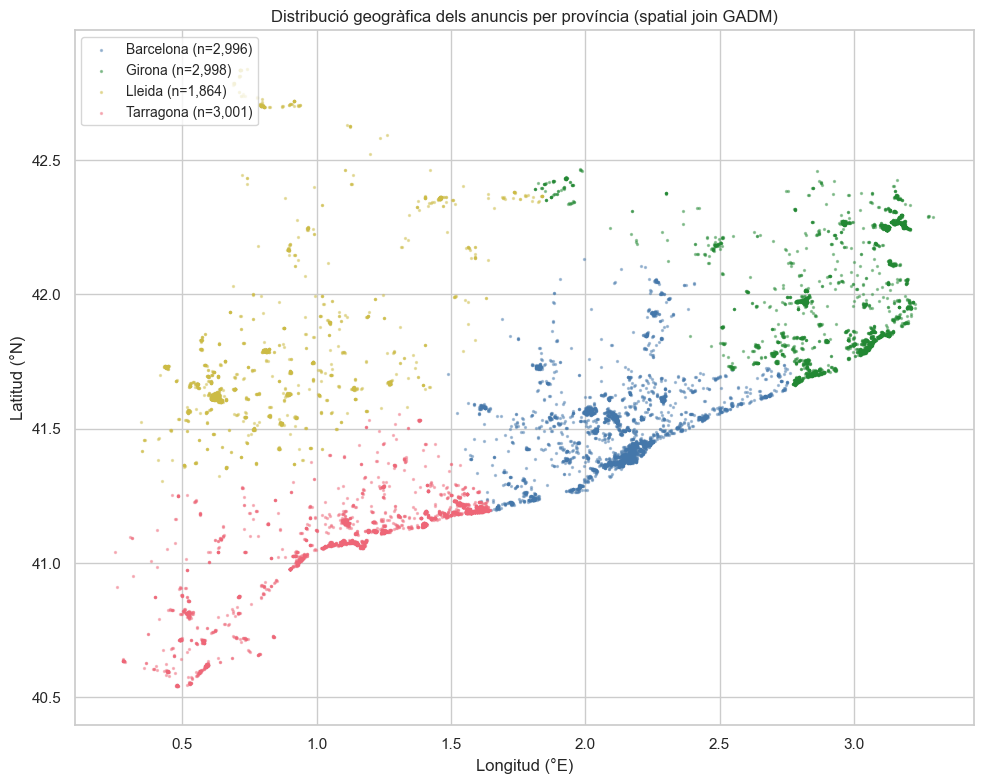

In [6]:
# Mapa de distribució per província (figura per a la memòria)
fig, ax = plt.subplots(figsize=(10, 8))
within = df[df["province"] != "Fora Catalunya"]
for prov, color in zip(["Barcelona", "Girona", "Lleida", "Tarragona"],
                       ["#4477AA", "#228833", "#CCBB44", "#EE6677"]):
    sub = within[within["province"] == prov]
    ax.scatter(sub["longitude"], sub["latitude"], s=2, alpha=0.4, c=color, label=f"{prov} (n={len(sub):,})")
ax.set_title("Distribució geogràfica dels anuncis per província (spatial join GADM)",
             fontsize=12)
ax.set_xlabel("Longitud (°E)")
ax.set_ylabel("Latitud (°N)")
ax.legend(loc="upper left", fontsize=10)
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="11_map_provinces_scatter")
plt.show()


## 5. Eliminar columnes constants

`operation` és sempre `"venta"` (la P1 ja filtrava). `is_new_development` és
sempre `False`. Cap senyal predictiva.


In [7]:
before_cols = set(df.columns)
df = cleaning.drop_constant_cols(df)
removed = before_cols - set(df.columns)
print(f"Eliminades: {sorted(removed)}")
print(f"Shape : {df.shape}")


Eliminades: ['is_new_development', 'operation']
Shape : (10864, 33)


## 6. Parsing de camps text a numèric

| Camp original         | Camp derivat       | Lògica |
|-----------------------|--------------------|--------|
| `construction_year`   | `antiguitat_anys`  | Bucket text → midpoint (p. ex. "Entre 30 y 50 años" → 40) |
| `floor`               | `floor_num`        | "3ª" → 3, "Bajo" → 0, "Entresuelo" → 0.5, "Semisótano" → -0.5 |
| `energy_cert`         | `energy_cert_ord`  | A=7 … G=1, NaN/desconegut = 0 |


In [8]:
df["antiguitat_anys"] = df["construction_year"].apply(features.parse_construction_year)
df["floor_num"]       = df["floor"].apply(features.parse_floor)
df["energy_cert_ord"] = df["energy_cert"].apply(features.energy_cert_to_ord)

df[["antiguitat_anys", "floor_num", "energy_cert_ord"]].describe().T


,count,mean,std,min,25%,50%,75%,max
antiguitat_anys,4117.0,42.961501,25.610136,2.5,25.0,40.0,75.0,75.0
floor_num,4072.0,2.316208,2.074981,-1.0,1.0,2.0,3.0,21.0
energy_cert_ord,10864.0,1.011138,1.644219,0.0,0.0,0.0,2.0,7.0


## 7. *Bug fix*: booleans de detall no observats

La P1 va executar-se majoritàriament en mode ràpid (sense `--with-details`).
Els camps booleans del detall (`has_terrace`, `has_balcony`, `has_parking`,
`has_air_conditioning`, `has_swimming_pool`, `has_garden`) van sortir per
defecte com a `False` als anuncis no visitats, en lloc de NaN. Això
contaminaria el modelat amb una "absència falsa" sistemàtica.

Proxy: si `energy_cert` és NaN → no s'ha visitat detall → masquem aquests
booleans com a NaN. Resultat: 7.144 anuncis (66%) passen a tenir
els booleans com a NaN explícit.


In [9]:
print("True/False per a cada has_* ABANS de mask:")
print(df[cleaning.DETAIL_BOOLEAN_COLS].apply(lambda c: c.value_counts(dropna=False)).fillna(0).astype(int))

df = cleaning.mask_unscraped_details(df)

print("\nTrue/False/NaN DESPRÉS de mask:")
print(df[cleaning.DETAIL_BOOLEAN_COLS].apply(lambda c: c.value_counts(dropna=False)).fillna(0).astype(int))


True/False per a cada has_* ABANS de mask:
       has_terrace  has_balcony  has_parking  has_air_conditioning  \
False         5274         9604         7387                  7614   
True          5590         1260         3477                  3250   

       has_swimming_pool  has_garden  
False               8173        8450  
True                2691        2414  

True/False/NaN DESPRÉS de mask:
       has_terrace  has_balcony  has_parking  has_air_conditioning  \
False         1607         2987         2314                  2218   
True          2113          733         1406                  1502   
<NA>          7144         7144         7144                  7144   

       has_swimming_pool  has_garden  
False               2723        2518  
True                 997        1202  
<NA>                7144        7144  


## 8. *Flag* d'anomalies (no eliminació)

En lloc d'eliminar files anòmales, les marquem amb columnes booleanes. Al
modelat es filtraran (`df[~df.is_price_anomaly]`), però es conserven al
dataset per a anàlisi específics i auditoria.


In [10]:
df = cleaning.flag_anomalies(df)
print(f"is_price_anomaly  : {df['is_price_anomaly'].sum():>4d} files "
      f"({df['is_price_anomaly'].mean()*100:.2f}%)")
print(f"is_rural          : {df['is_rural'].sum():>4d} files "
      f"({df['is_rural'].mean()*100:.2f}%)")


is_price_anomaly  :  143 files (1.32%)
is_rural          :   54 files (0.50%)


## 9. Imputació estratificada per `property_type`

Per a les variables numèriques amb missings, imputem amb la **mediana del
mateix `property_type`** en lloc de la mediana global. Justificació: la
distribució de `rooms` d'un *Pis* (mediana ≈ 3) i d'una *Casa* (mediana ≈ 5)
divergeixen prou per justificar l'estratificació.

Camps imputats: `rooms`, `bathrooms`, `area_m2`, `antiguitat_anys`, `floor_num`.


In [11]:
to_impute = ["rooms", "bathrooms", "area_m2", "antiguitat_anys", "floor_num"]
print("NaN abans:")
print(df[to_impute].isna().sum().to_string())

df = features.impute_by_property_type(df, cols=to_impute)

print("\nNaN després:")
print(df[to_impute].isna().sum().to_string())


NaN abans:
rooms               372
bathrooms           366
area_m2             113
antiguitat_anys    6747
floor_num          6792

NaN després:
rooms              0
bathrooms          0
area_m2            0
antiguitat_anys    0
floor_num          0


In [12]:
# Mediana per property_type — taula per a la memòria
medians = df.groupby("property_type")[to_impute].median().round(1)
medians


,rooms,bathrooms,area_m2,antiguitat_anys,floor_num
property_type,,,,,
Apartamento,2.0,1.0,70.0,40.0,2.0
Atico,3.0,2.0,99.0,40.0,4.0
Casa,4.0,2.0,223.0,40.0,2.0
Chalet,4.0,3.0,249.0,40.0,2.0
Duplex,3.0,2.0,115.0,25.0,2.0
Estudio,1.0,1.0,34.0,40.0,1.0
Loft,1.5,1.0,77.5,75.0,1.0
Piso,3.0,1.0,87.0,40.0,2.0


## 10. Feature engineering

| Feature derivada     | Definició |
|----------------------|-----------|
| `log_price_eur`      | log(price_eur), NaN si ≤ 0 |
| `log_price_per_m2`   | log(price_per_m2) — **variable objectiu del modelat** |
| `log_area_m2`        | log(area_m2) |
| `dist_bcn_km`        | Distància geodèsica (Haversine) a Plaça Catalunya |
| `n_anuncis_locality` | Volum del mercat local — proxy de popularitat |


In [13]:
df = features.add_log_features(df)
df = features.add_distance_to_bcn(df)
df = features.add_market_density(df)

new_feats = ["log_price_eur", "log_price_per_m2", "log_area_m2",
             "dist_bcn_km", "n_anuncis_locality"]
df[new_feats].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
log_price_eur,10760.0,12.533384,0.863004,9.615805,12.037654,12.554967,13.038982,16.811243
log_price_per_m2,10649.0,7.577414,0.916351,-0.916291,7.236562,7.746357,8.120027,9.998798
log_area_m2,10864.0,4.961872,0.81781,0.0,4.406719,4.795791,5.4161,14.197535
dist_bcn_km,10859.0,79.860874,45.225823,0.1347,49.065348,83.931478,118.235442,200.841871
n_anuncis_locality,10859.0,154.803665,179.260653,1.0,21.0,85.0,220.0,612.0


C:\Users\Gerard\AppData\Local\Temp\ipykernel_25192\3625306700.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="province", y="log_price_per_m2", order=order,


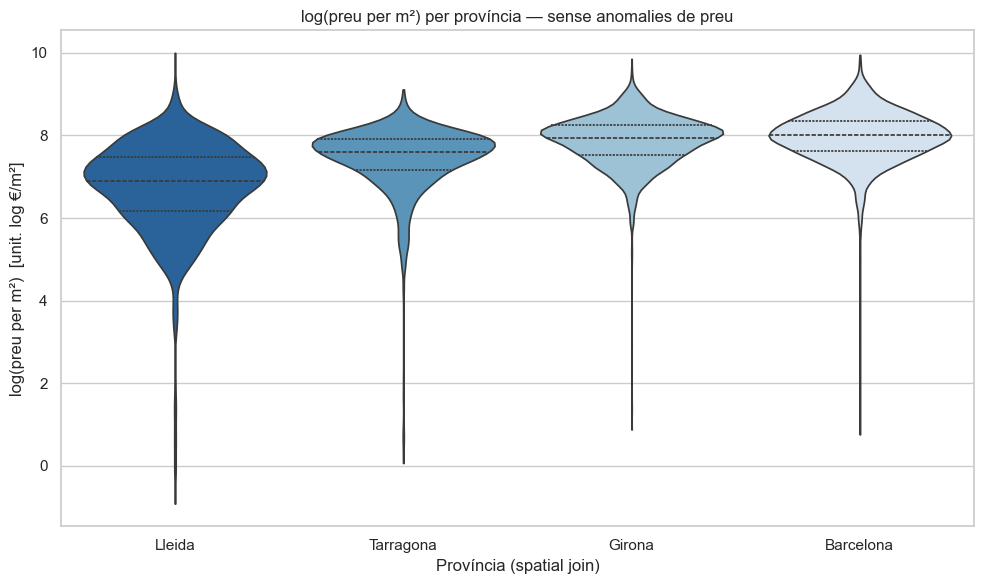

In [14]:
# Distribució de log_price_per_m2 per província — figura clau per a la memòria
fig, ax = plt.subplots(figsize=(10, 6))
order = (df[df["province"] != "Fora Catalunya"]
         .groupby("province")["log_price_per_m2"].median()
         .sort_values().index)
sub = df[(df["province"] != "Fora Catalunya") & (~df["is_price_anomaly"])]
sns.violinplot(data=sub, x="province", y="log_price_per_m2", order=order,
               ax=ax, palette="Blues_r", inner="quartile", cut=0)
ax.set_title("log(preu per m²) per província — sense anomalies de preu",
             fontsize=12)
ax.set_xlabel("Província (spatial join)")
ax.set_ylabel("log(preu per m²)  [unit. log €/m²]")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="12_violin_log_price_per_m2_by_province")
plt.show()


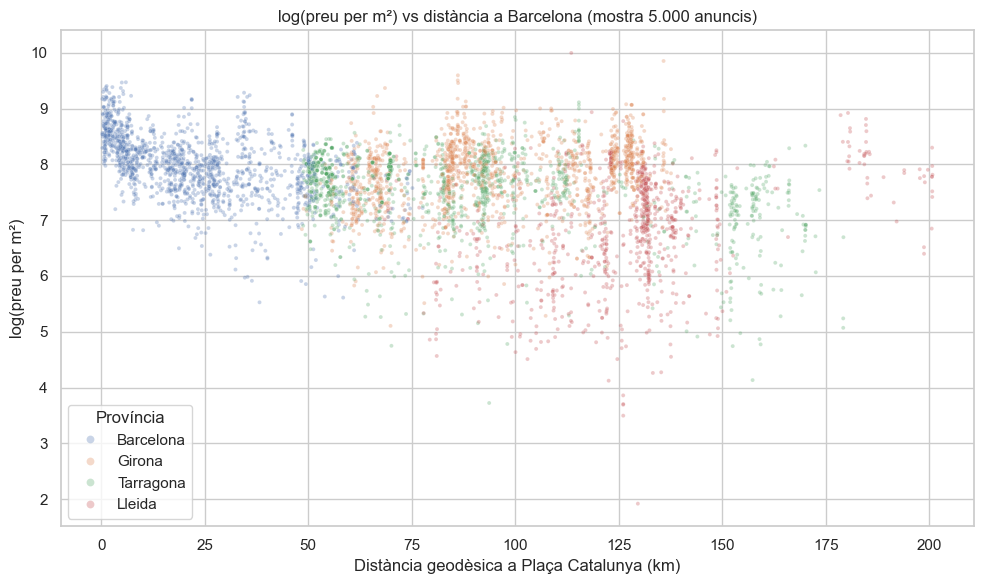

In [15]:
# Relació log_price_per_m2 vs dist_bcn_km (premium urbà esperat)
fig, ax = plt.subplots(figsize=(10, 6))
sub = df[(~df["is_price_anomaly"]) & (~df["is_rural"]) & (df["province"] != "Fora Catalunya")]
sns.scatterplot(data=sub.sample(min(len(sub), 5000), random_state=RANDOM_STATE),
                x="dist_bcn_km", y="log_price_per_m2",
                hue="province", alpha=0.3, s=8, ax=ax)
ax.set_title("log(preu per m²) vs distància a Barcelona (mostra 5.000 anuncis)",
             fontsize=12)
ax.set_xlabel("Distància geodèsica a Plaça Catalunya (km)")
ax.set_ylabel("log(preu per m²)")
ax.legend(title="Província", markerscale=2)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="13_scatter_log_price_vs_dist_bcn")
plt.show()


## 11. Validació post-neteja — *cleaning report*

Resum estructural de cada columna abans/després: dtype, missings, cardinalitat,
i un `status` que classifica el canvi (`unchanged`, `imputed`, `masked`,
`retyped`, `added`, `removed`).


In [16]:
report = stats.cleaning_report(df_raw, df)
report.to_csv(TAB_DIR / "cleaning_report.csv", index=False, encoding="utf-8-sig")
print(f"Desat: {TAB_DIR / 'cleaning_report.csv'}")
report


Desat: C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\outputs\tables\cleaning_report.csv


,column,dtype_raw,dtype_clean,n_missing_raw,n_missing_clean,n_unique_raw,n_unique_clean,delta_missing,status
0,advertiser_name,object,object,0.0,0.0,1166.0,1166.0,0,unchanged
1,advertiser_type,object,object,0.0,0.0,2.0,2.0,0,unchanged
2,antiguitat_anys,,float64,NaN,0.0,NaN,6.0,<NA>,added
3,area_m2,float64,float64,113.0,0.0,835.0,835.0,-113,imputed
4,bathrooms,float64,float64,366.0,0.0,20.0,20.0,-366,imputed
5,condition,object,object,5476.0,5476.0,4.0,4.0,0,unchanged
6,construction_year,object,object,6747.0,6747.0,6.0,6.0,0,unchanged
7,description,object,object,0.0,0.0,9745.0,9745.0,0,unchanged
8,dist_bcn_km,,float64,NaN,5.0,NaN,9598.0,<NA>,added
9,district,object,object,4237.0,4237.0,224.0,224.0,0,unchanged


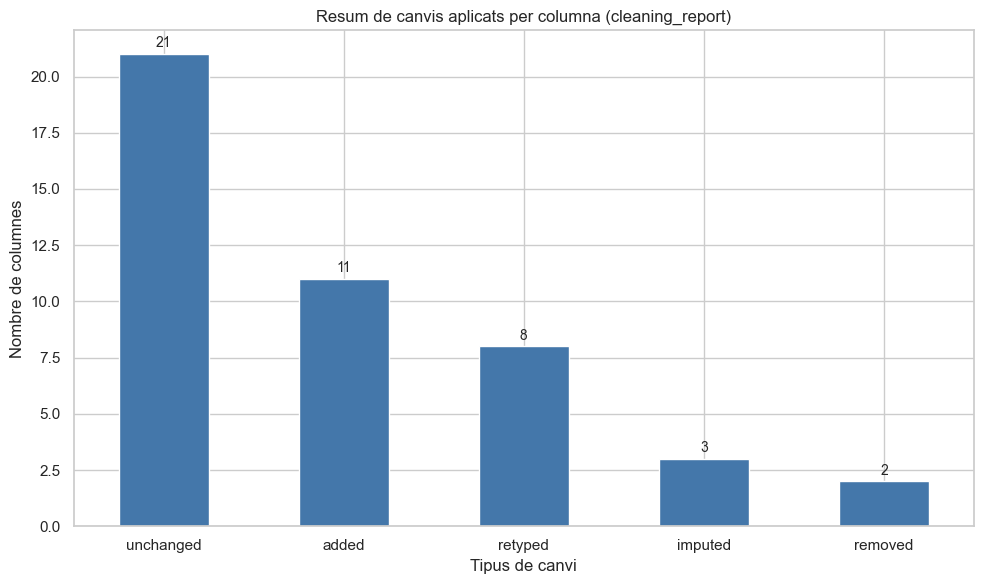

In [17]:
# Barplot de canvis més importants
fig, ax = plt.subplots(figsize=(10, 6))
counts = report["status"].value_counts()
counts.plot(kind="bar", ax=ax, color="#4477AA")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)
ax.set_title("Resum de canvis aplicats per columna (cleaning_report)", fontsize=12)
ax.set_xlabel("Tipus de canvi")
ax.set_ylabel("Nombre de columnes")
plt.xticks(rotation=0)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="14_cleaning_report_summary")
plt.show()


## 12. Persistència

Desem el dataset processat en dos formats:
- **Parquet** (`data/processed/pisos_clean.parquet`): format primari, preserva
  dtypes exactes (incloent NaN dins booleans), compressed.
- **CSV** (`data/processed/pisos_clean.csv`): per a compatibilitat amb Excel
  i amb el corrector que vulgui obrir-lo sense Python.


In [18]:
parquet_path = PROC_DIR / "pisos_clean.parquet"
csv_path     = PROC_DIR / "pisos_clean.csv"

df.to_parquet(parquet_path, index=False)
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"Parquet: {parquet_path} ({parquet_path.stat().st_size / 1e6:.2f} MB)")
print(f"CSV    : {csv_path} ({csv_path.stat().st_size / 1e6:.2f} MB)")
print(f"\nShape final: {df.shape}")
print(f"Dtypes:\n{df.dtypes.value_counts().to_string()}")


Parquet: C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\data\processed\pisos_clean.parquet (4.00 MB)
CSV    : C:\Users\Gerard\Desktop\Master\Tipologia_de_les_dades\pract2-tipologia\data\processed\pisos_clean.csv (10.66 MB)

Shape final: (10864, 43)
Dtypes:
object            21
float64           15
bool               3
datetime64[ns]     2
int64              1
Int64              1


## 13. Conclusions de la neteja

- **Cap fila eliminada.** Totes les anomalies estan marcades amb flag i es
  poden filtrar segons context. Mantenim els 10.864 anuncis originals.
- **Província coberta al 100%** via spatial join sobre GADM nivell 2. Només
  5 anuncis cauen a "Fora Catalunya" (0.05%) — molt probablement errors de
  geocoding a la frontera amb Aragó.
- **Coordenades recuperades:** 142/142 (100%). El patró del factor 1000 era
  consistent — un sol bug del scraper de la P1.
- **Bug dels booleans de detall corregit:** 7.144 valors falsos `False`
  passen a NaN explícit (per als 6 camps `has_*` de detall).
- **Imputació estratificada per `property_type`** aplicada a `rooms`,
  `bathrooms`, `area_m2`, `antiguitat_anys`, `floor_num`. Resultat: 0 NaN
  en variables numèriques principals.
- **Features afegides:** `province`, `antiguitat_anys`, `floor_num`,
  `energy_cert_ord`, `log_price_eur`, `log_price_per_m2`, `log_area_m2`,
  `dist_bcn_km`, `n_anuncis_locality`, `is_price_anomaly`, `is_rural`.
- **Dataset final:** 10.864 anuncis × 43 columnes, persistit en parquet i CSV.

**Següent pas (FASE 3):** estadística inferencial — proves d'hipòtesi sobre
diferències de `log_price_per_m2` per província, tipologia i antiguitat;
verificació de normalitat (Shapiro-Wilk, D'Agostino) per justificar t-test
vs Mann-Whitney; intervals de confiança bootstrap.
